## Housing Data Analysis
A comprehensive analysis spanning exploratory analysis to predictive modeling.

###  1 - Import Libraries & Dataset Connection

In [ ]:
# --- Imports (consolidated) ---
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load DataFrame once at top ---    
df = pd.read_csv("D:/Housing.csv")
print('Loaded DataFrame with shape:', df.shape)


Loaded DataFrame with shape: (508, 13)


###  2 - Dataset Overview
Quick summary of the dataset structure and basic information.

In [17]:
print("\n" + "="*70)
print("DATASET OVERVIEW")
print("="*70)

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names ({len(df.columns)}):")
print(df.columns.tolist())

print(f"\nData Types:")
print(df.dtypes)

print(f"\nFirst 5 rows:")
print(df.head())

print(f'\nLast 5 rows:')
print(df.tail())

print(f"\nDescriptive Statistics (Numeric):")
print(df.describe())

print(f"\nMissing Values:")
print(df.isnull().sum())



DATASET OVERVIEW

Dataset Shape: (508, 13)

Column Names (13):
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Data Types:
price               float64
area                float64
bedrooms            float64
bathrooms           float64
stories               int64
mainroad             object
guestroom            object
basement             object
hotwaterheating      object
airconditioning      object
parking             float64
prefarea             object
furnishingstatus     object
dtype: object

First 5 rows:
        price    area  bedrooms  bathrooms  stories mainroad guestroom  \
0  13300000.0  7420.0       4.0        2.0        3      yes        no   
1  12250000.0  8960.0       4.0        4.0        4      yes        no   
2  12250000.0  9960.0       3.0        2.0        2      yes        no   
3  12215000.0  7500.0       4.0        2.0        2      yes  

###  3 - Dataset Summary
Run `df.info()` and `df.describe()` to view dataset structure and summary statistics.

In [18]:
#  3 - Dataset Summary
print('\n 3 - Dataset Summary')

print('\nDataFrame info:')
df.info()

print('\nDescriptive statistics:')
print(df.describe(include='all'))



 3 - Dataset Summary

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             506 non-null    float64
 1   area              506 non-null    float64
 2   bedrooms          507 non-null    float64
 3   bathrooms         505 non-null    float64
 4   stories           508 non-null    int64  
 5   mainroad          505 non-null    object 
 6   guestroom         506 non-null    object 
 7   basement          507 non-null    object 
 8   hotwaterheating   507 non-null    object 
 9   airconditioning   506 non-null    object 
 10  parking           507 non-null    float64
 11  prefarea          508 non-null    object 
 12  furnishingstatus  507 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 51.7+ KB

Descriptive statistics:
               price          area    bedrooms   bathrooms     

###  4 - Missing Value Check
Check counts and percentages of missing values per column.

In [4]:
#  4 - Missing Value Check
print('\n 4 - Missing Value Check')

missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_percent': missing_pct.round(2)})
print(missing_df[missing_df['missing_count']>0].sort_values('missing_percent', ascending=False))



 4 - Missing Value Check
                  missing_count  missing_percent
bathrooms                     3             0.59
mainroad                      3             0.59
price                         2             0.39
area                          2             0.39
guestroom                     2             0.39
airconditioning               2             0.39
bedrooms                      1             0.20
basement                      1             0.20
hotwaterheating               1             0.20
parking                       1             0.20
furnishingstatus              1             0.20


###  5 - Handle Missing Data
Strategy: numeric → median fill; categorical → mode fill. Show counts before/after.

In [5]:
#  5 — Handle Missing Data
print('\n 5 — Handle Missing Data')

# Missing before
print('\nMissing value counts (before):')
print(df.isnull().sum()[df.isnull().sum()>0])

# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().any():
        med = df[col].median()
        df[col].fillna(med, inplace=True)

# Fill categorical columns with mode
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().any():
        mode = df[col].mode()
        fill_val = mode.iloc[0] if not mode.empty else 'Unknown'
        df[col].fillna(fill_val, inplace=True)

# Missing after
print('\nMissing value counts (after):')
print(df.isnull().sum()[df.isnull().sum()>0])



 5 — Handle Missing Data

Missing value counts (before):
price               2
area                2
bedrooms            1
bathrooms           3
mainroad            3
guestroom           2
basement            1
hotwaterheating     1
airconditioning     2
parking             1
furnishingstatus    1
dtype: int64

Missing value counts (after):
Series([], dtype: int64)


###  6 - Univariate Analysis (Bedrooms Count)
Countplot for `bedrooms`. Single chart only; follow with a short conclusion.


 6 - Univariate Analysis (Bedrooms Count)


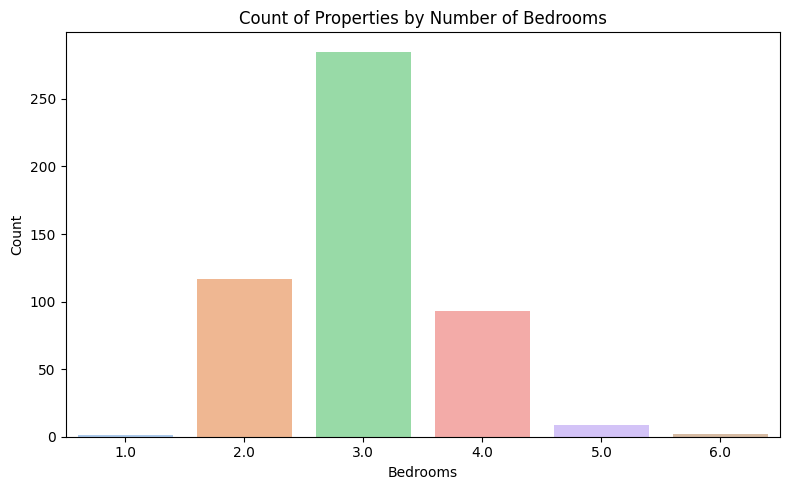

In [19]:
#  6 - Univariate Analysis (Bedrooms Count)
print('\n 6 - Univariate Analysis (Bedrooms Count)')

if 'bedrooms' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x='bedrooms', palette='pastel')
    plt.title('Count of Properties by Number of Bedrooms')
    plt.xlabel('Bedrooms')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("Column 'bedrooms' not found in dataset.")


**Conclusion (Bedrooms Count):**
- This chart shows the distribution of properties by `bedrooms`. Use it to identify the most common property sizes and detect class imbalance for modeling.

###  7 - Bivariate Analysis (Bedrooms vs Price)
Boxplot: Price distribution by number of `bedrooms`. Single chart only; follow with a short conclusion.


BIVARIATE ANALYSIS - Relationships Between Variables

Price by Number of Bedrooms:


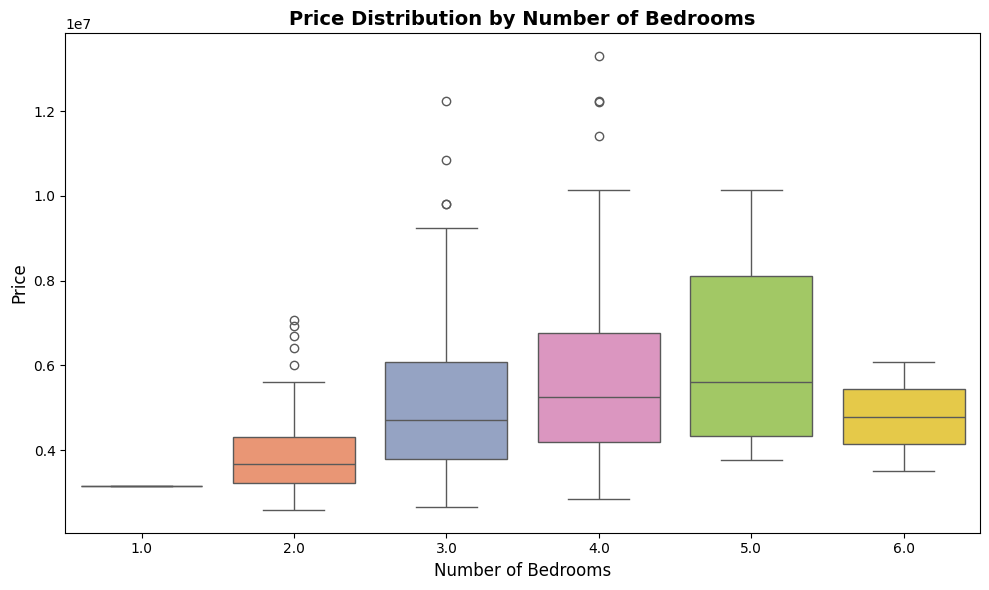

In [7]:
print("\n" + "="*70)
print("BIVARIATE ANALYSIS - Relationships Between Variables")
print("="*70)

# Price vs Bedrooms
if 'bedrooms' in df.columns and 'price' in df.columns:
    print("\nPrice by Number of Bedrooms:")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=df, x='bedrooms', y='price', palette='Set2', ax=ax)
    ax.set_title("Price Distribution by Number of Bedrooms", fontsize=14, fontweight='bold')
    ax.set_xlabel("Number of Bedrooms", fontsize=12)
    ax.set_ylabel("Price", fontsize=12)
    plt.tight_layout()
    plt.show()



**Conclusion (Bedrooms vs Price):**
- The boxplot reveals how price varies across different bedroom counts, showing price ranges, medians, and potential outliers for each bedroom category. Use this to understand pricing patterns by property size.


 7 - Bivariate-2 Analysis (Line Charts)


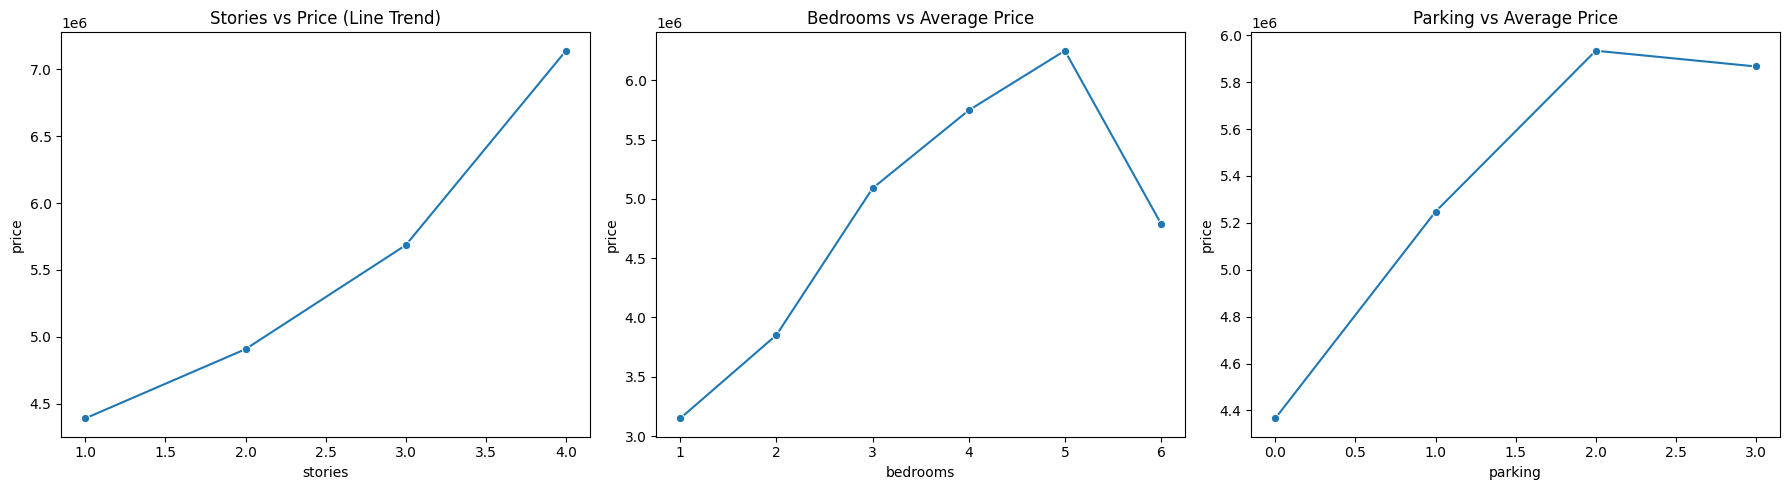

In [8]:
#  Bivariate-2 Analysis (Line Charts - Single Row)
print('\n 7 - Bivariate-2 Analysis (Line Charts)')

fig, axes = plt.subplots(1, 3, figsize=(18,5))  # single row

# --- Chart 1: stories vs Price (Line Trend) ---
if 'stories' in df.columns and 'price' in df.columns:
    stories_avg = df.groupby('stories')['price'].mean().reset_index()
    sns.lineplot(
            data=stories_avg,
        x='stories',
        y='price',
        marker='o',
        ax=axes[0]
    )
    axes[0].set_title('Stories vs Price (Line Trend)')


# --- Chart 2: Bedrooms vs Avg Price ---
if 'bedrooms' in df.columns:
    bedroom_avg = df.groupby('bedrooms')['price'].mean().reset_index()
    sns.lineplot(
        data=bedroom_avg,
        x='bedrooms',
        y='price',
        marker='o',
        ax=axes[1]
    )
    axes[1].set_title('Bedrooms vs Average Price')


# --- Chart 3: Parking/Mainroad vs Avg Price ---
if 'parking' in df.columns:
    parking_avg = df.groupby('parking')['price'].mean().reset_index()
    sns.lineplot(
        data=parking_avg,
        x='parking',
        y='price',
        marker='o',
        ax=axes[2]
    )
    axes[2].set_title('Parking vs Average Price')

elif 'mainroad' in df.columns:
    road_avg = df.groupby('mainroad')['price'].mean().reset_index()
    sns.lineplot(
        data=road_avg,
        x='mainroad',
        y='price',
        marker='o',
        ax=axes[2]
    )
    axes[2].set_title('Mainroad vs Average Price')


plt.tight_layout()
plt.show()

**Conclusion :**
- This single chart visualizes three variables simultaneously; use it to spot how bedroom count and parking/mainroad status relate to area and price.

### 8 - Data Visulization

#### Chart 1: Price by Furnishing Status




DATA VISUALIZATION - Furnishing Status vs Price


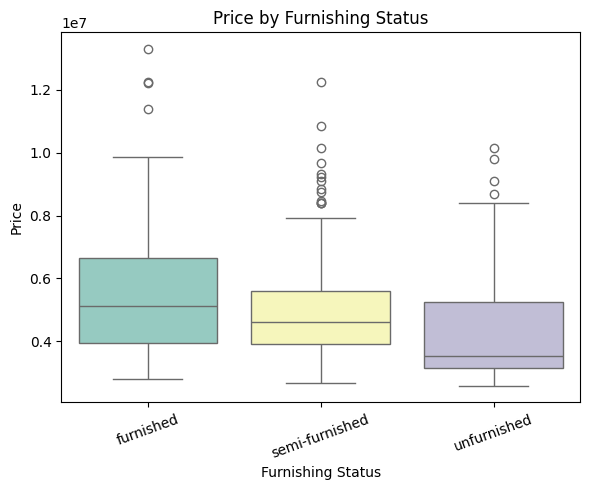

In [9]:

print("\nDATA VISUALIZATION - Furnishing Status vs Price")

if 'furnishingstatus' in df.columns and 'price' in df.columns:
    plt.figure(figsize=(6,5))
    sns.boxplot(data=df, x='furnishingstatus', y='price',palette='Set3')
    plt.title('Price by Furnishing Status')
    plt.xlabel('Furnishing Status')
    plt.ylabel('Price')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found.")

**Conclusion:**
- Different furnishing statuses show varying price distributions, indicating that furnishing type significantly impacts property valuation.
- Identifies median price differences across furnishing types and reveals pricing anomalies (outliers) for each category.
- Use this insight to understand how furnishing status affects property marketability and pricing strategy.

---

#### Chart 2: Guestroom Availability Distribution


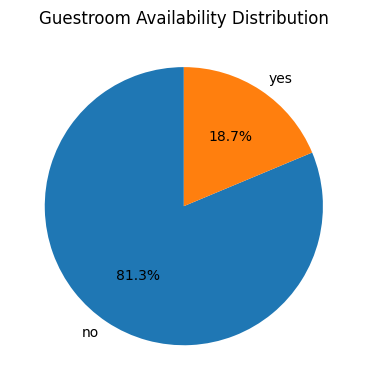

In [10]:

if 'guestroom' in df.columns:
    counts = df['guestroom'].value_counts()

    plt.figure(figsize=(4,4))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Guestroom Availability Distribution')
    plt.tight_layout()
    plt.show()
else:
    print("Column 'guestroom' not found.")

**Conclusion:**
- Shows the market dominance: what percentage of properties have guestrooms versus those without.
- Reveals market trends in property amenities and buyer preferences for guest accommodations.
- Useful for understanding the competitive landscape and niche positioning of properties in the market.

---

#### Chart 3: Basement vs Furnishing Status



DATA VISUALIZATION - Basement vs Furnishing Status


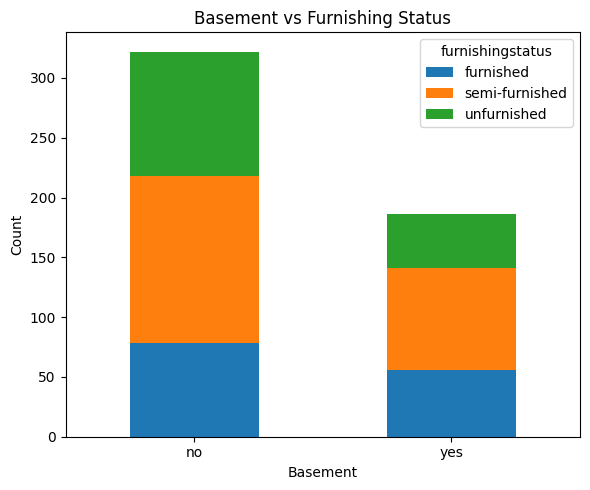

In [11]:
# DATA VISUALIZATION - Stacked Bar Chart

print("\nDATA VISUALIZATION - Basement vs Furnishing Status")

if 'basement' in df.columns and 'furnishingstatus' in df.columns:
    cross_tab = pd.crosstab(df['basement'], df['furnishingstatus'])

    cross_tab.plot(kind='bar', stacked=True, figsize=(6,5))
    plt.title('Basement vs Furnishing Status')
    plt.xlabel('Basement')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found.")

**Conclusion:**
- Reveals associations between basement availability and furnishing status, showing how these features co-occur in the market.
- Helps identify patterns: e.g., whether furnished properties more often have basements compared to unfurnished ones.
- Useful for understanding correlations between categorical variables and for feature engineering in predictive models.

---

#### Chart 4: Air Conditioning Availability



DATA VISUALIZATION - Air Conditioning Count


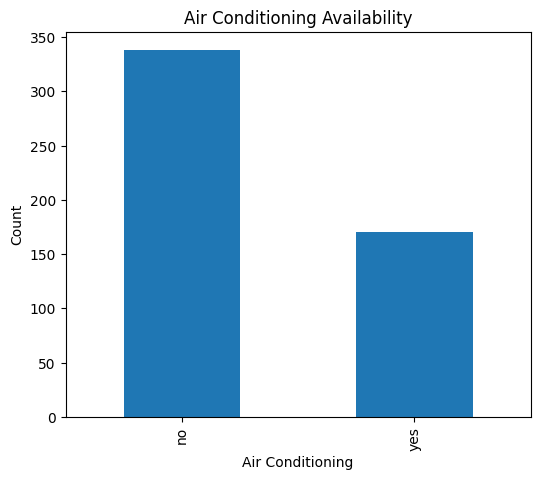

In [12]:
# DATA VISUALIZATION - Air Conditioning Count

print("\nDATA VISUALIZATION - Air Conditioning Count")

if 'airconditioning' in df.columns:
    counts = df['airconditioning'].value_counts()

    plt.figure(figsize=(6,5))
    counts.plot(kind='bar')
    plt.title('Air Conditioning Availability')
    plt.ylabel('Count')
    plt.xlabel('Air Conditioning')
    plt.show()
else:
    print("Column 'airconditioning' not found.")

**Conclusion:**
- Indicates how common air conditioning is across the entire property dataset.
- Helps assess whether AC is a standard amenity available in most properties or a premium feature in few properties.
- Provides insight into market demand, property specifications, and useful for filtering and segmentation strategies.

---

###  9 - Advanced EDA (Correlation Heatmap & Multivariate Analysis)
Single correlation heatmap for numerical features with a short conclusion.


 9 - Advanced EDA (Correlation Heatmap & Multivariate Analysis )


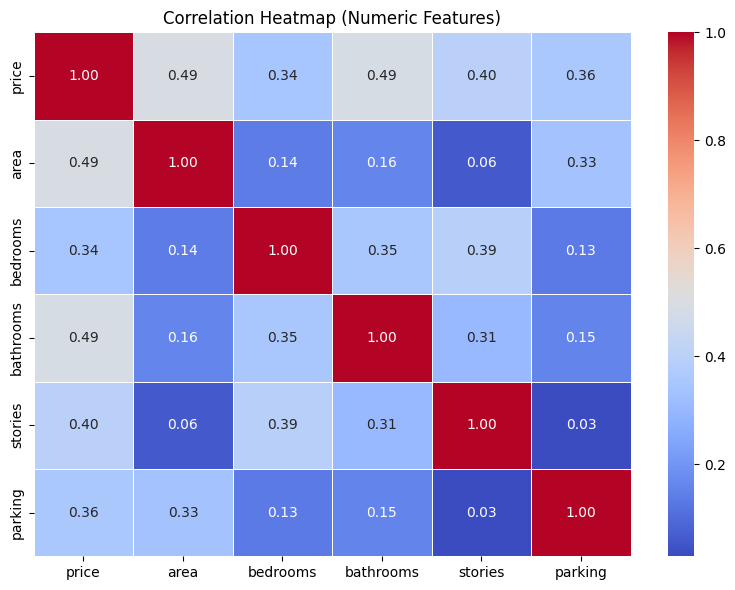

In [13]:
#  9 - Advanced EDA (Correlation Heatmap & Multivariate Analysis)
print('\n 9 - Advanced EDA (Correlation Heatmap & Multivariate Analysis )')

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) >= 2:
    plt.figure(figsize=(8,6))
    corr = df[num_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap (Numeric Features)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')


**Conclusion (Correlation Heatmap):**
- The heatmap highlights strong and weak linear relationships between numeric features; use it to select candidate predictors and detect multicollinearity.